<a href="https://colab.research.google.com/github/KINJAL1710P/KINJAL_PRAJAPATI_GITHUB/blob/main/student_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
'''
Student-Performance-Prediction
│
├── student_performance.csv
├── student_prediction.py
├── requirements.txt
├── README.md
└── model.pkl
'''

'\nStudent-Performance-Prediction\n│\n├── student_performance.csv\n├── student_prediction.py\n├── requirements.txt\n├── README.md\n└── model.pkl\n'

In [3]:
pip install pandas numpy scikit-learn matplotlib seaborn joblib

In [5]:
import pandas
import numpy
import sklearn
import matplotlib
import seaborn
import joblib

In [7]:
csv_data = '''StudyHours,Attendance,PreviousScore,Result
2,60,40,Fail
3,65,45,Fail
4,70,50,Fail
5,75,55,Pass
6,80,60,Pass
7,85,65,Pass
8,90,70,Pass
1,50,35,Fail
9,95,80,Pass
3,68,48,Fail
10,98,90,Pass
5,78,58,Pass
2,62,42,Fail
7,88,67,Pass
4,72,53,Pass
'''

with open('student_performance.csv', 'w') as f:
    f.write(csv_data)

print('student_performance.csv created successfully.')

student_performance.csv created successfully.


In [8]:
import pandas as pd

df = pd.read_csv("student_performance.csv")

print("First 5 Rows")
print(df.head())

print("\nDataset Info")
print(df.info())

print("\nStatistics")
print(df.describe())

First 5 Rows
   StudyHours  Attendance  PreviousScore Result
0           2          60             40   Fail
1           3          65             45   Fail
2           4          70             50   Fail
3           5          75             55   Pass
4           6          80             60   Pass

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   StudyHours     15 non-null     int64 
 1   Attendance     15 non-null     int64 
 2   PreviousScore  15 non-null     int64 
 3   Result         15 non-null     object
dtypes: int64(3), object(1)
memory usage: 612.0+ bytes
None

Statistics
       StudyHours  Attendance  PreviousScore
count   15.000000   15.000000       15.00000
mean     5.066667   75.733333       57.20000
std      2.711527   13.760537       15.24186
min      1.000000   50.000000       35.00000
25%      3.000000   66.50000

In [10]:
!python student_prediction.py

python3: can't open file '/content/student_prediction.py': [Errno 2] No such file or directory


In [ ]:
%%writefile student_prediction.py
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import joblib

# Load the dataset
df = pd.read_csv('student_performance.csv')

# Convert 'Result' column to numerical format (0 for Fail, 1 for Pass)
df['Result'] = df['Result'].map({'Fail': 0, 'Pass': 1})

# Define features (X) and target (y)
X = df[['StudyHours', 'Attendance', 'PreviousScore']]
y = df['Result']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Make predictions and evaluate the model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

# Save the trained model
joblib.dump(model, 'model.pkl')
print("Model saved as model.pkl")

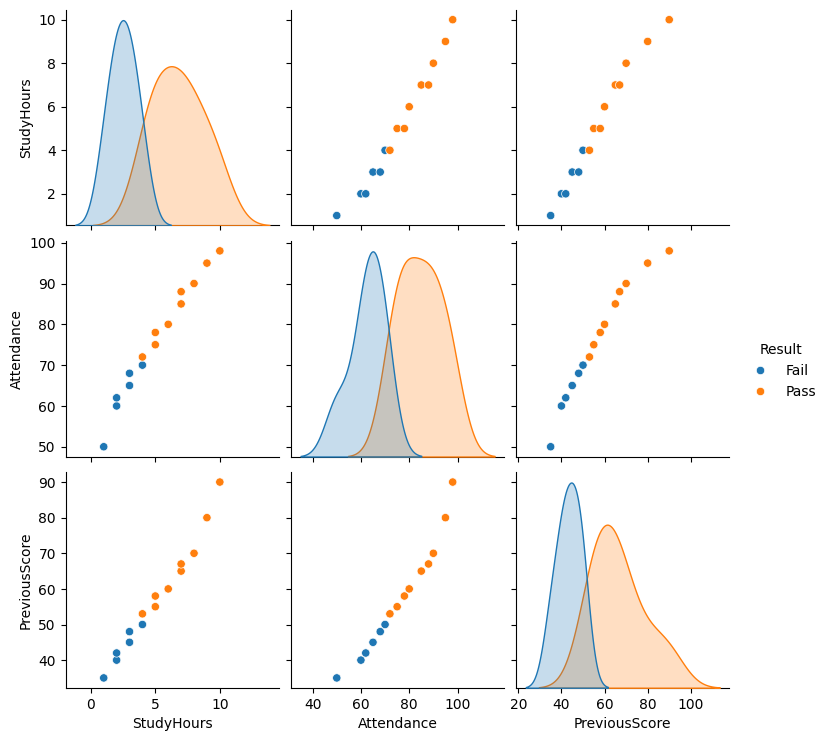

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, hue="Result")
plt.show()

In [12]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Result"] = encoder.fit_transform(df["Result"])

In [13]:
Fail = 0
Pass = 1

In [14]:
X = df[["StudyHours","Attendance","PreviousScore"]]
y = df["Result"]

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

model.fit(X_train, y_train)

DecisionTreeClassifier()

In [17]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[0 1 0]


In [18]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)

print("\nClassification Report")
print(classification_report(y_test, y_pred))


Accuracy: 1.0

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [19]:
import joblib

joblib.dump(model, "model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [20]:
hours = float(input("Enter Study Hours: "))
attendance = float(input("Enter Attendance: "))
score = float(input("Enter Previous Score: "))

prediction = model.predict([[hours, attendance, score]])

if prediction[0] == 1:
    print("Student Will PASS")
else:
    print("Student Will FAIL")

Enter Study Hours: 15
Enter Attendance: 70
Enter Previous Score: 89
Student Will FAIL


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
